<center><h1> Predicción de éxito en trasplantes de órganos en México usando Machine Learning.</h1>

## Universidad Autónoma de Sinaloa<br>
## Licenciatura en Física
<br>

## Docente:
### Isabel Domínguez Jiménez
<br>

## Estudiante:  
### Akira Cruz Marentes
<br>

### 11 de diciembre de 2025
</center>



# 1. Introducción
El éxito de un trasplante de órgano en fase temprana se observa al momento que el órgano funciona correctamente y no es rechazado por el sistema inmune del paciente. Esto depende fuertemente de diversos factores, como la relación sanguinea con el donante y la institución donde se realiza la cirugía.

Las complicaciones presentadas durante la cirugía y la fase temprana post-cirugía perjudican considerablemente la supervivencia del órgano donado a mediano y largo plazo.

Con este análisis se desea aumentar la probabilidad de éxito en este tipo de  cirugías, ayudando al paciente a elegir la mejor opción de institución y que los médicos pongan más atención a los pacientes de riesgo de acuerdo al modelo.

## 2. Objetivos

### Objetivo principal:
Construir un modelo de aprendizaje automatizado que prediga el resultado de trasplante en base a una cantidad mínima de variables.

### Objetivos secundarios
1. Entender los factores que influyeron en el éxito de las cirugías.
2. Identificar patrones de origen biológico, institucional y geográfico.
3. Proveer una lista de mejores instituciones públicas y privadas en base a la tasa de éxito.

## 3. Descripción del Dataset
El dataset `Trasplante de órganos y tejidos` es un conjunto de datos del Centro Nacional de Trasplantes (CENATRA) donde se registran las cirugías realizadas por trimestre (2020 - actualidad) en la República Mexicana.

Este es un problema de clasificación, ya que mi variable objetivo (resultado_24hrs) es binaria. Por lo que mi modelo, de acuerdo a los datos de una cirugía, tiene qué predecir a qué clase pertenece (Exitoso, No exitoso).

El dataset contiene 22 columnas y más de 27 mil filas de información.
### Variables relevantes para el análisis:

- **codigo_sexo**: (2 = Femenino, 1 = Masculino)
- **institucion**: Institución donde se realizó la cirugía (IMSS, ISSSTE, PRIVADO, etc)
- **codigo_entidad_federativa_trasplante**: Código del estado de la república donde se realizó la cirguía
- **establecimiento**: Hospital/clínica donde se realizó la cirugía
- **institucion_organo**: Institución que provee el órgano (IMSS, EXTRANJERO, PRIVADO, etc)
- **codigo_entidad_federativa_organo**: Código del estado de la república donde proviene el órgano
- **grupo_sanguineo_receptor**: Grupo sanguíneo del paciente (O, A, B, AB)
- **rh**: Factor rh del paciente (postivo, negativo)
- **edad_al_trasplante_anios**: Edad del paciente
- **fecha_trasplante**: Fecha de cuando se realizó la cirugía
- **organo**: Órgano que fue trasplantado al paciente
- **tipo_trasplante**: (Vivo, cadavérico, no aplica)
- **relacion**: Relación sanguínea de donante-receptor (Relacionado, No relacionado)
- **resultado_24hrs**: Variable objetivo (Exitoso, No exitoso)



## 4. Exploración de Datos (EDA)
Primero cargamos los datos, seleccionamos y renombramos las columnas relevantes, y elaboramos nuestro primer resumen de los datos.

Además, exploraremos las distribuciones de cada variable por medio de histogramas y también analizaremos sus distrubuciones con respecto a la variable objetivo.

In [2]:
# Cargamos las librerías a utilizar, y elegimos una paleta de colores para las gráficas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from dython.nominal import associations

sns.set_palette("flare")

In [3]:
# Datos obtenidos desde https://www.datos.gob.mx/dataset/trasplantes_organos_tejidos

# Unimos todos los datos en un solo DataFrame:

folder = []
for i in range(5):
  for k in range(1,5):
    folder.append(pd.read_csv(f"/content/202{i}_{k}.csv"))
folder.append(pd.read_csv("/content/2025_1.csv"))
df = pd.concat(folder, axis = 0, ignore_index = True)
print("Primeras 5 filas del Dataset")
df.head()

Primeras 5 filas del Dataset


,sexo,codigo_sexo,institucion,entidad_federativa_trasplante,codigo_entidad_federativa_trasplante,establecimiento,institucion_organo,entidad_federativa_organo,codigo_entidad_federativa_organo,entidad_federativa_origen,...,fecha_registro_comite,fecha_trasplante,organo,tipo_trasplante,relacion,resultado_24hrs,entidad_federativa_trasplante_etq,entidad_federativa_organo_etq,entidad_federativa_origen_etq,entidad_federativa_residencia_etq
0,femenino,2,IMSS,Jalisco,14,Unidad Medica de Alta Especialidad Hospital de...,SSE,Jalisco,14,Jalisco,...,2006-12-22,2020-01-28,riñón,cadáver,no aplica,no disponible,NaN,NaN,NaN,NaN
1,femenino,2,SEDENA,Ciudad de México,9,Hospital Central Militar,IMSS,Ciudad de México,9,Guerrero,...,2007-08-07,2020-01-24,córnea,cadáver,no aplica,no disponible,NaN,NaN,NaN,NaN
2,femenino,2,IMSS,Puebla,21,U.M.A.E. Hospital de Especialidades C.M.N. Gra...,IMSS,Puebla,21,Puebla,...,2009-03-27,2020-02-21,riñón,cadáver,no aplica,no disponible,NaN,NaN,NaN,NaN
3,masculino,1,IMSS,Jalisco,14,Unidad Medica de Alta Especialidad Hospital de...,IMSS,Jalisco,14,Michoacán,...,2009-11-20,2020-01-25,riñón,cadáver,no aplica,no disponible,NaN,NaN,NaN,NaN
4,femenino,2,IMSS,Guanajuato,11,Hospital de Especialidades No. 1 del Centro Me...,IMSS,Guanajuato,11,Guanajuato,...,2010-10-03,2020-02-27,riñón,cadáver,no aplica,no disponible,NaN,NaN,NaN,NaN


In [4]:
# Filtramos el DataFrame, tomando las columnas a analizar:

columnas_de_interés = ["codigo_sexo", "institucion", "entidad_federativa_trasplante",
                       "institucion_organo", "entidad_federativa_organo",
                       "grupo_sanguineo_receptor", "rh", "edad_al_trasplante_anios",
                       "fecha_trasplante", "organo", "tipo_trasplante", "relacion", "resultado_24hrs"]
df_base = df.copy()
df = df[columnas_de_interés]

In [5]:
# Renombramos las columnas con un nombre más corto:

mapper = {
    "codigo_sexo" : "sexo",
    "entidad_federativa_trasplante" : "estado_trasplante",
    "entidad_federativa_organo" : "estado_organo",
    "edad_al_trasplante_anios" : "edad"
}
df.rename(mapper = mapper, axis = 1, inplace = True)
print("Primeras 5 filas del Dataset filtrado: ")
df.head()

Primeras 5 filas del Dataset filtrado: 


,sexo,institucion,estado_trasplante,institucion_organo,estado_organo,grupo_sanguineo_receptor,rh,edad,fecha_trasplante,organo,tipo_trasplante,relacion,resultado_24hrs
0,2,IMSS,Jalisco,SSE,Jalisco,B,positivo,25,2020-01-28,riñón,cadáver,no aplica,no disponible
1,2,SEDENA,Ciudad de México,IMSS,Ciudad de México,no disponible,no disponible,74,2020-01-24,córnea,cadáver,no aplica,no disponible
2,2,IMSS,Puebla,IMSS,Puebla,O,positivo,47,2020-02-21,riñón,cadáver,no aplica,no disponible
3,1,IMSS,Jalisco,IMSS,Jalisco,A,positivo,47,2020-01-25,riñón,cadáver,no aplica,no disponible
4,2,IMSS,Guanajuato,IMSS,Guanajuato,O,positivo,48,2020-02-27,riñón,cadáver,no aplica,no disponible


In [6]:
print("Información del dataset:")
df.info()

print("\nColumnas del dataset:")
print(df.columns.tolist())

# Conteo de valores
print("\nDistribución de instituciones donde se realizó el trasplante:")
print(df['institucion'].value_counts())

print("\nDistribución de instituciones donde proviene el órgano:")
print(df['institucion_organo'].value_counts())

print("\nDistribución grupos sanguineos:")
print(df['grupo_sanguineo_receptor'].value_counts())

print("\nDistribución rh:")
print(df['rh'].value_counts())

print("\nDistribución organos:")
print(df['organo'].value_counts())

print("\nDistribución de relación entre donante y receptor:")
print(df['relacion'].value_counts(normalize = True))

print("\nDistribución de resultado en 24 horas:")
print(df['resultado_24hrs'].value_counts(normalize=True))

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27361 entries, 0 to 27360
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   sexo                      27361 non-null  int64 
 1   institucion               27361 non-null  object
 2   estado_trasplante         27361 non-null  object
 3   institucion_organo        27361 non-null  object
 4   estado_organo             27361 non-null  object
 5   grupo_sanguineo_receptor  27361 non-null  object
 6   rh                        27361 non-null  object
 7   edad                      27361 non-null  int64 
 8   fecha_trasplante          27361 non-null  object
 9   organo                    27361 non-null  object
 10  tipo_trasplante           27361 non-null  object
 11  relacion                  27361 non-null  object
 12  resultado_24hrs           27361 non-null  object
dtypes: int64(2), object(11)
memory usage: 2.7+ MB

Colu

###Revisión de datos faltantes y transformación de datos:

In [7]:
print("Número de duplicados:", df.duplicated().sum())
print("\nValores faltantes:\n")


df.isna().count()   # 0 = Con contenido, 1 = valor faltante

# De acuerdo al resultado, no hay valores nulos

Número de duplicados: 69

Valores faltantes:



,0
sexo,27361
institucion,27361
estado_trasplante,27361
institucion_organo,27361
estado_organo,27361
grupo_sanguineo_receptor,27361
rh,27361
edad,27361
fecha_trasplante,27361
organo,27361


In [8]:
# Eliminamos las filas duplicadas y nos aseguramos de que ya no hay filas duplicadas.

df = df.drop_duplicates(ignore_index = True)
df.duplicated().sum()

np.int64(0)

En este Dataset, los valores faltantes son puestos como "no disponible" (como es visto en la sección anterior), además de contar con valores "no aplica"
en trasplante de córnea (tipo de sangre, rh) y en relación cuando el trasplante es cadaverico.

Consideraremos solo los órganos con un mínimo de 1000 datos y consideraremos como "No exitoso" la categoría "No disponible" de la variable objetivo, ya que este puede indicar que el órgano donado todavía no se adapata bien, ya sea por alguna complicación o simplemente rechazo, lo que reduce considerablemente la supervivencia del órgano a mediano y largo plazo.

Similar a la variable de órganos, reduciremos la cantidad de clases en las variables de instituciones por bajo conteo de datos.

In [9]:
# Mapas para reducir categorías/transformar variables
mapa = {
    "IMSS" : "IMSS",
    "PRIVADO" : "PRIVADO",
    "SSA" : "SSA",
    "SSE" : "SSE",
    "ISSSTE" : "ISSSTE",
    "IMSS-BIENESTAR": "Otro",
    "IMSS-BIENESTAR/SSA/SSE" : "Otro",
    "SEDENA" : "Otro",
    "PEMEX" : "Otro",
    "SEMAR" : "Otro",
    "SNTE" : "Otro",
    "EXTRANJERO" : "EXTRANJERO"
}

mapa_resultado = {
    "no exitoso" : 0,
    "no disponible" : 0,
    "exitoso" : 1
}

mapa_relación = {
    "no aplica" : 0,
    "No relacionado" : 0,
    "Parentesco/Relacionado" : 1
}

# Aplicamos la transformación de datos
df["institucion"] = df["institucion"].map(mapa)
df["institucion_organo"] = df["institucion_organo"].map(mapa)

grupos_sanguineos_deseados = ["A", "B", "O", "AB", "no aplica"]
órganos_deseados = ["córnea", "riñón", "hígado"]
df = df[(df["grupo_sanguineo_receptor"].isin(grupos_sanguineos_deseados)) & (df["rh"] != "no disponible")
         & (df["resultado_24hrs"] != "no aplica") & (df["organo"].isin(órganos_deseados))]

df["resultado_24hrs"] = df["resultado_24hrs"].map(mapa_resultado)
df["relacion"] = df["relacion"].map(mapa_relación)

# Observamos cambios
df.tail()

,sexo,institucion,estado_trasplante,institucion_organo,estado_organo,grupo_sanguineo_receptor,rh,edad,fecha_trasplante,organo,tipo_trasplante,relacion,resultado_24hrs
27287,2,PRIVADO,Ciudad de México,EXTRANJERO,Extranjero,O,positivo,80,2025-03-12,córnea,córnea importada,0,1
27288,2,PRIVADO,Ciudad de México,EXTRANJERO,Extranjero,no aplica,no aplica,47,2025-03-22,córnea,córnea importada,0,1
27289,1,PRIVADO,Ciudad de México,EXTRANJERO,Extranjero,no aplica,no aplica,54,2025-03-28,córnea,córnea importada,0,1
27290,2,PRIVADO,Ciudad de México,EXTRANJERO,Extranjero,O,positivo,66,2025-03-28,córnea,córnea importada,0,1
27291,1,PRIVADO,Ciudad de México,EXTRANJERO,Extranjero,no aplica,no aplica,72,2025-03-28,córnea,córnea importada,0,1


### Outliers

Como nuestra única variable numérica es "edad", utilizaremos el método de cuartiles para identificar datos atípicos.

Número de outliers en Edad: 0



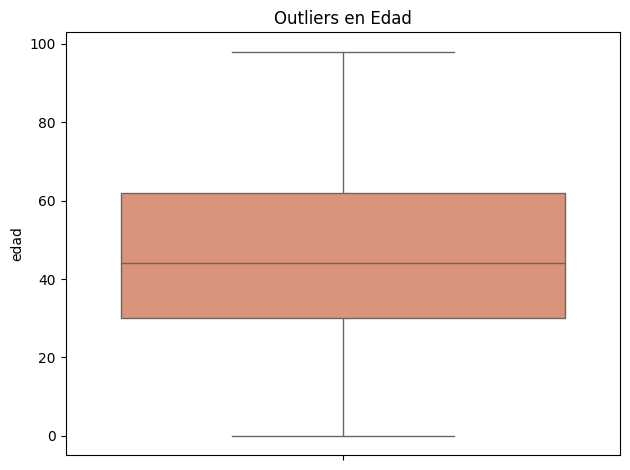

In [10]:
def outliers(df, col):
    z_scores = np.abs( (df[col] - df[col].mean()) / (df[col].std()) )
    return z_scores > 3

f, ax = plt.subplots()


sns.boxplot(data = df, y = "edad", ax = ax)
ax.set(title = "Outliers en Edad")


# Imprimir número de outliers
print(f"Número de outliers en Edad: {sum(outliers(df, "edad"))}\n" )
plt.tight_layout()
plt.show()

### Análisis univariado

  A continuación están los histogramas de cada variable con la intención de visualizar fácilmente la proporción de estos.

/tmp/ipython-input-1805834836.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Hombre' if label.get_text() == '1' else 'Mujer' for label in axes[0,1].get_xticklabels()])  # Reemplazamos valores numéricos por strings


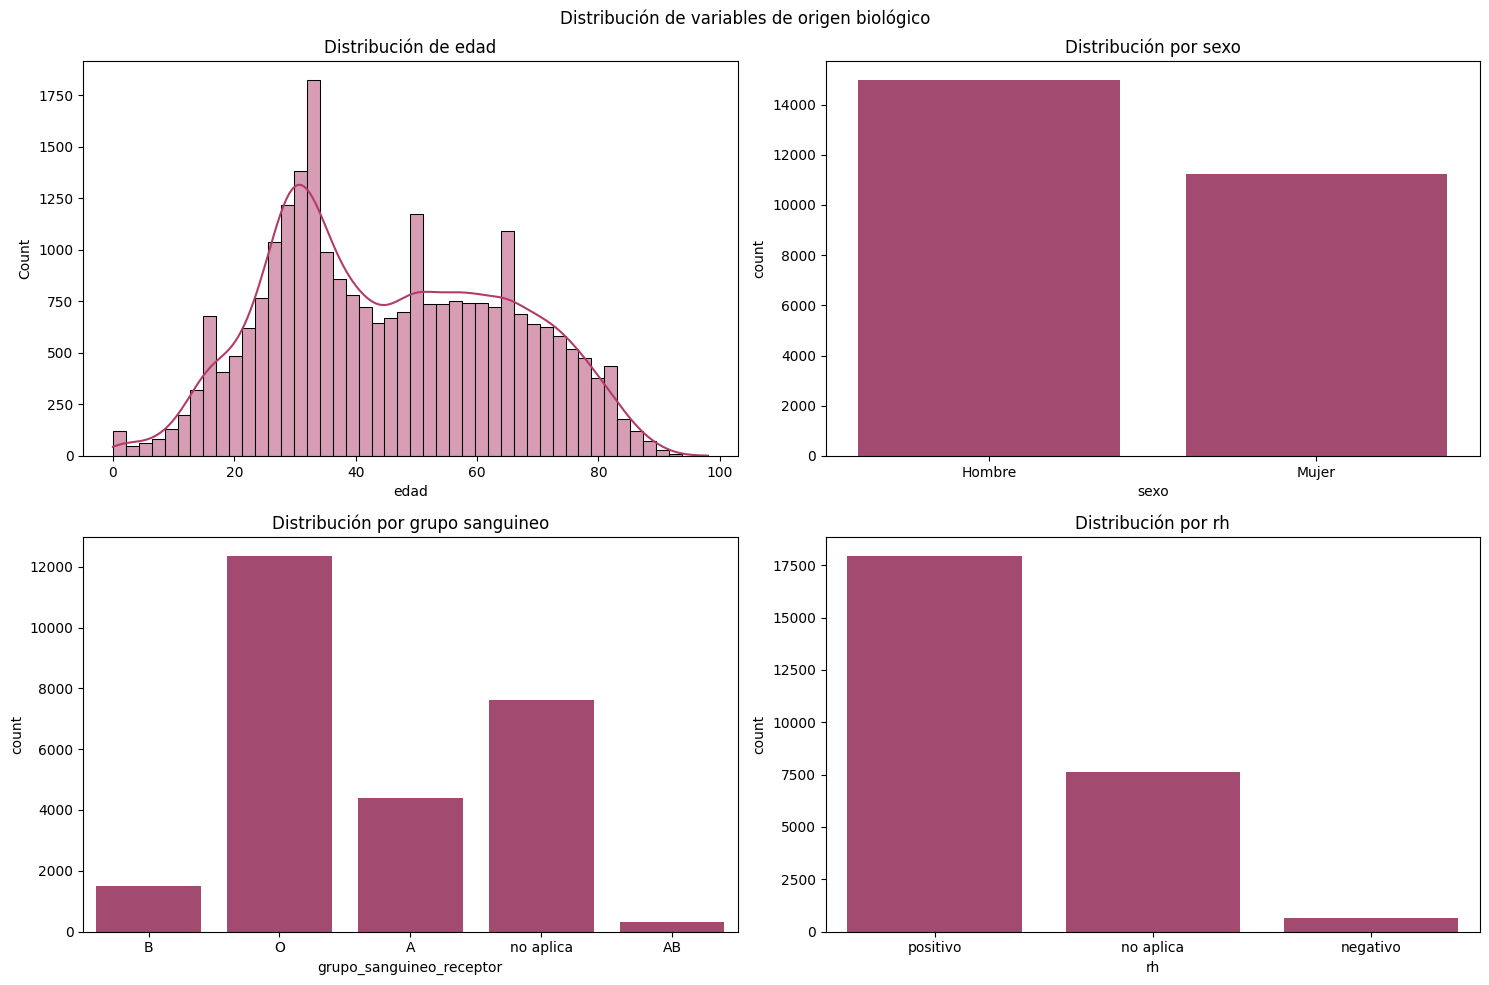

In [11]:
flare_4 = sns.color_palette("flare")[3]  # Color a usar

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Distribución de variables de origen biológico")

sns.histplot(df["edad"], kde = True, ax = axes[0,0], color = flare_4)
axes[0,0].set_title("Distribución de edad")

sns.countplot(data = df, x = "sexo", ax = axes[0,1], color = flare_4)
axes[0,1].set_title("Distribución por sexo")
axes[0,1].set_xticklabels(['Hombre' if label.get_text() == '1' else 'Mujer' for label in axes[0,1].get_xticklabels()])  # Reemplazamos valores numéricos por strings

sns.countplot(data = df, x = "grupo_sanguineo_receptor", ax = axes[1,0], color = flare_4)
axes[1,0].set_title("Distribución por grupo sanguineo")

sns.countplot(data = df, x = "rh", ax = axes[1,1], color = flare_4)
axes[1,1].set_title("Distribución por rh")

plt.tight_layout()
plt.show()

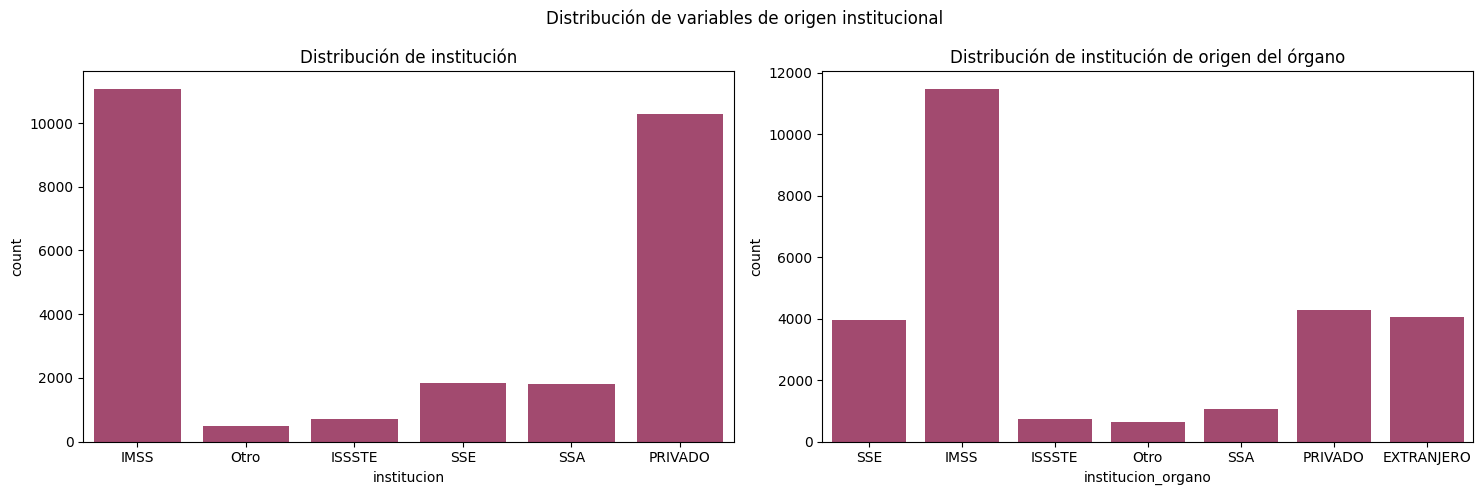

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Distribución de variables de origen institucional")

sns.countplot(data = df, x = "institucion", ax = axes[0], color = flare_4)
axes[0].set_title("Distribución de institución")

sns.countplot(data = df, x = "institucion_organo", ax = axes[1], color = flare_4)
axes[1].set_title("Distribución de institución de origen del órgano")

plt.tight_layout()
plt.show()

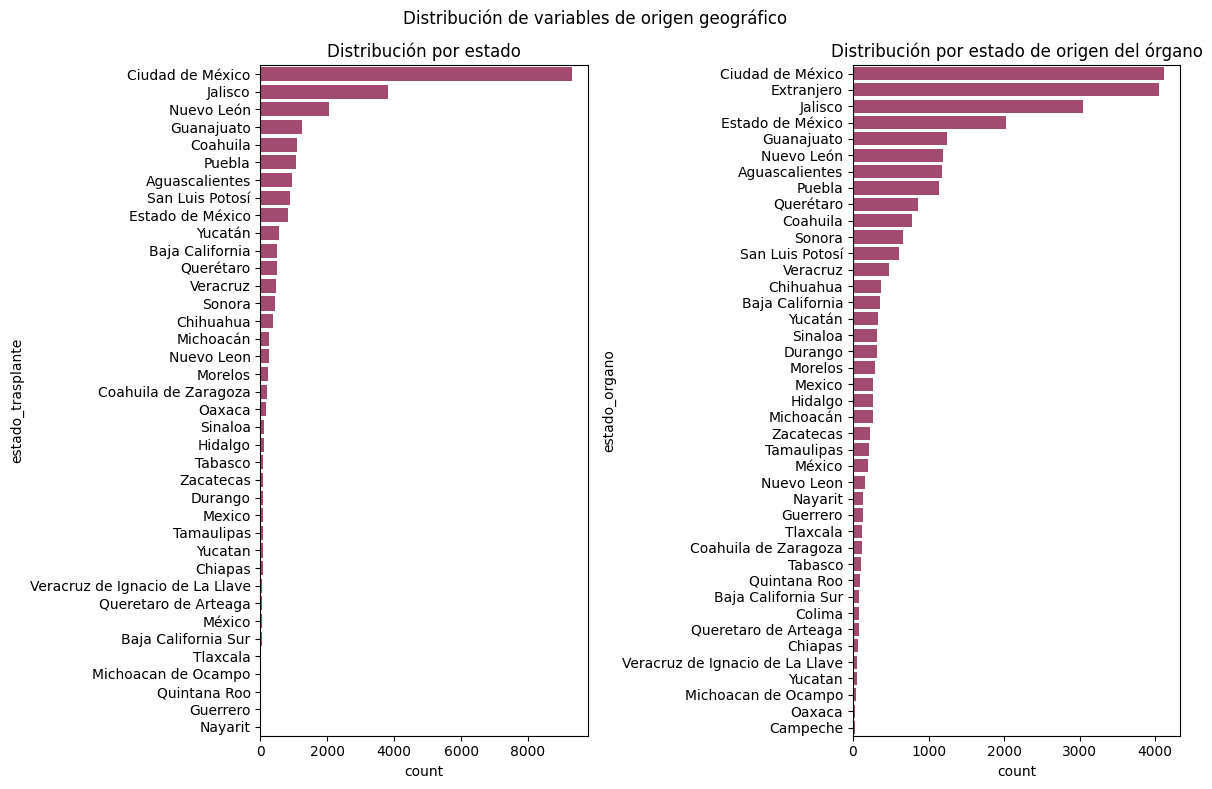

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
fig.suptitle("Distribución de variables de origen geográfico")

# Order by count for estado_trasplante
estado_trasplante_orden = df['estado_trasplante'].value_counts().index  # Ordenamos de mayor a menor
sns.countplot(data = df, y = "estado_trasplante", ax = axes[0], color = flare_4, order=estado_trasplante_orden)
axes[0].set_title("Distribución por estado")

# Ordenamos de  forma descendente los estados por conteo
estado_organo_orden = df['estado_organo'].value_counts().index
sns.countplot(data = df, y = "estado_organo", ax = axes[1], color = flare_4, order=estado_organo_orden)
axes[1].set_title("Distribución por estado de origen del órgano")

plt.tight_layout()
plt.show()

/tmp/ipython-input-874658660.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Relacionado' if label.get_text() == '1' else 'No relacionado' for label in axes[1,0].get_xticklabels()])
/tmp/ipython-input-874658660.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(['Éxitoso' if label.get_text() == '1' else 'No exitoso' for label in axes[1,1].get_xticklabels()])


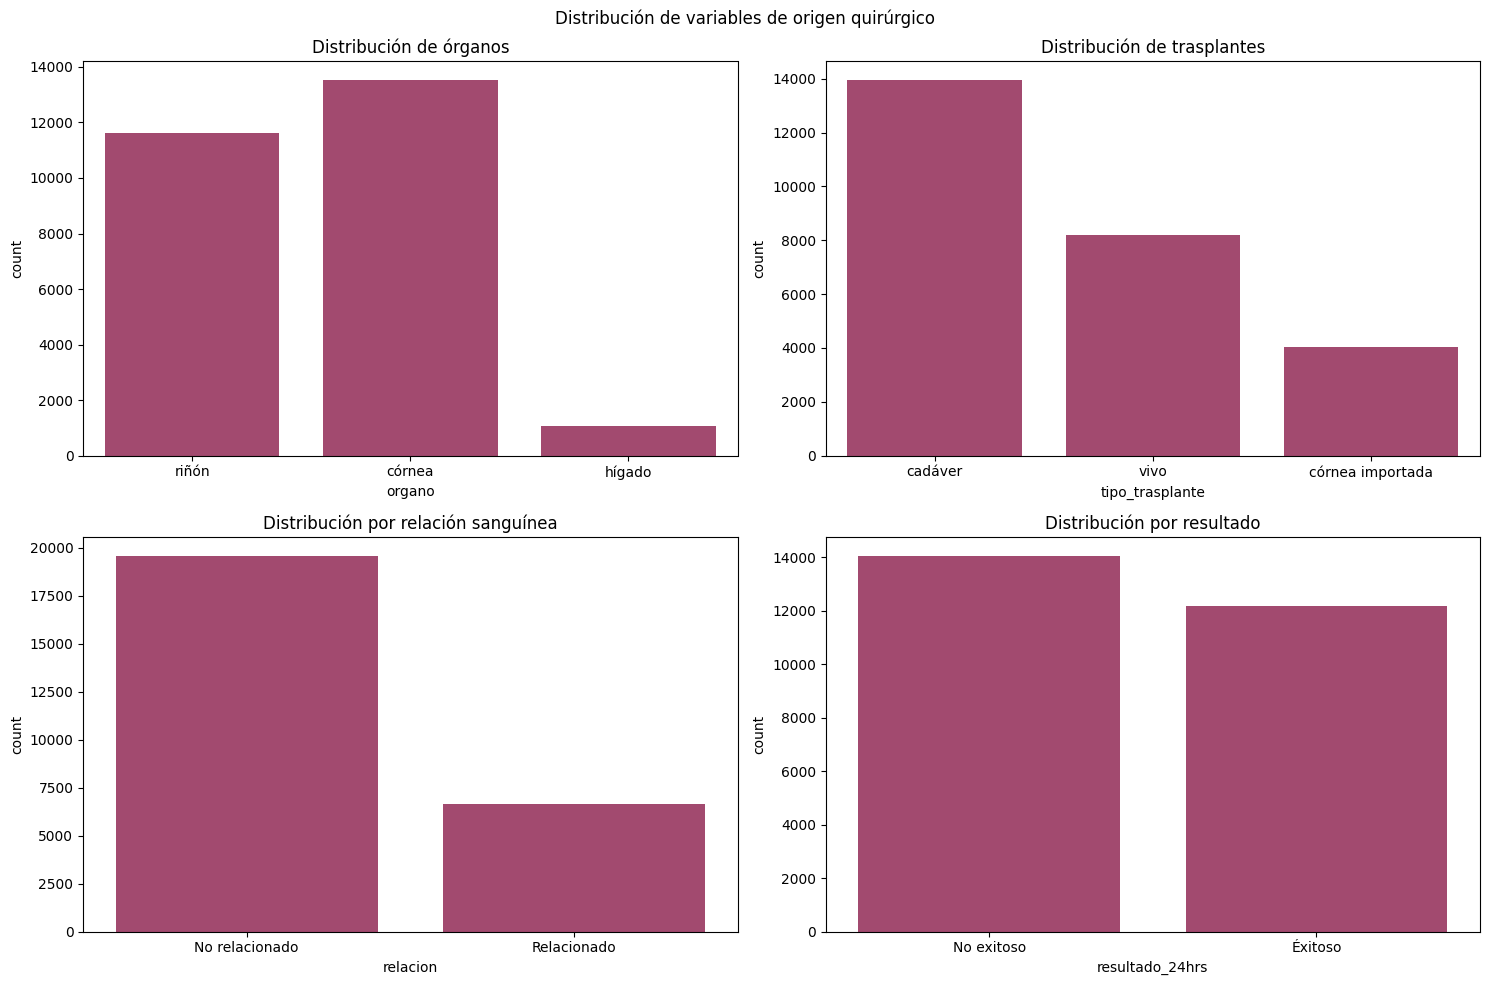

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Distribución de variables de origen quirúrgico")

sns.countplot(data = df, x = "organo", ax = axes[0,0], color = flare_4)
axes[0,0].set_title("Distribución de órganos")

sns.countplot(data = df, x = "tipo_trasplante", ax = axes[0,1], color = flare_4)
axes[0,1].set_title("Distribución de trasplantes")

sns.countplot(data = df, x = "relacion", ax = axes[1,0], color = flare_4)
axes[1,0].set_title("Distribución por relación sanguínea")
axes[1,0].set_xticklabels(['Relacionado' if label.get_text() == '1' else 'No relacionado' for label in axes[1,0].get_xticklabels()])

sns.countplot(data = df, x = "resultado_24hrs", ax = axes[1,1], color = flare_4)
axes[1,1].set_title("Distribución por resultado")
axes[1,1].set_xticklabels(['Éxitoso' if label.get_text() == '1' else 'No exitoso' for label in axes[1,1].get_xticklabels()])

plt.tight_layout()
plt.show()

###Análisis bivariado

En esta sección visualizaremos la importancia de cada clase en el resultado final, además veremos la correlación que tienen las variables entre sí y

In [15]:
# Normalizamos el DataFrame para que los gráficos sean en proporción: Varible(Exitoso)+ Variable(No exitoso) = 100%

dict_df_normalizados = {}

for col in df.columns:
  # Saltamos nuestra variable objetivo
  if col == "resultado_24hrs":
    continue
  dict_df_normalizados[f"{col}"] = pd.DataFrame(df.groupby(f"{col}")["resultado_24hrs"].value_counts(normalize = True))

/tmp/ipython-input-3111652454.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Exitoso' if label.get_text() == '1' else 'No exitoso' for label in axes[0,0].get_xticklabels()])
/tmp/ipython-input-3111652454.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Hombre' if label.get_text() == '1' else 'Mujer' for label in axes[0,1].get_xticklabels()])


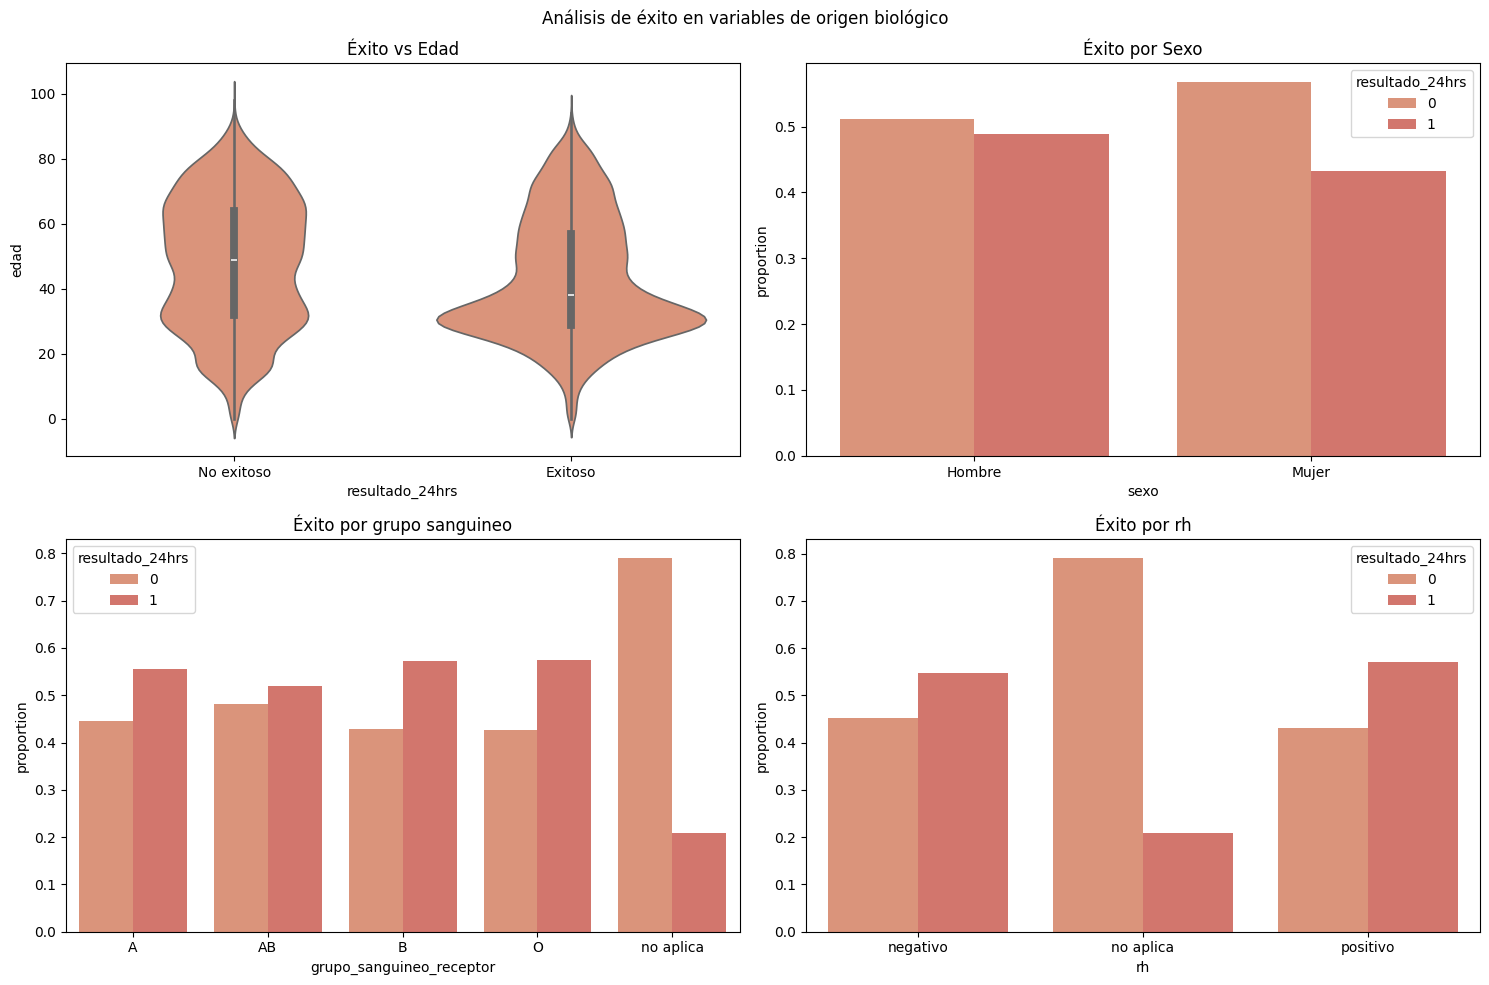

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Análisis de éxito en variables de origen biológico")

sns.violinplot(data = df, x = "resultado_24hrs", y = "edad", ax = axes[0,0])  # Grafica parecida a boxplot, pero también muestra la densidad de la muestra
axes[0,0].set_title("Éxito vs Edad")
axes[0,0].set_xticklabels(['Exitoso' if label.get_text() == '1' else 'No exitoso' for label in axes[0,0].get_xticklabels()])

sexo = dict_df_normalizados["sexo"]
sns.barplot(data = sexo, x = "sexo", ax = axes[0,1], hue = "resultado_24hrs", y = "proportion")
axes[0,1].set_title("Éxito por Sexo")
axes[0,1].set_xticklabels(['Hombre' if label.get_text() == '1' else 'Mujer' for label in axes[0,1].get_xticklabels()])

sangre = dict_df_normalizados["grupo_sanguineo_receptor"]
sns.barplot(data = sangre, x = "grupo_sanguineo_receptor", ax = axes[1,0], hue = "resultado_24hrs", y = "proportion")
axes[1,0].set_title("Éxito por grupo sanguineo")

rh = dict_df_normalizados["rh"]
sns.barplot(data = rh, x = "rh", ax = axes[1,1], hue = "resultado_24hrs", y = "proportion")
axes[1,1].set_title("Éxito por rh")

plt.tight_layout()
plt.show()

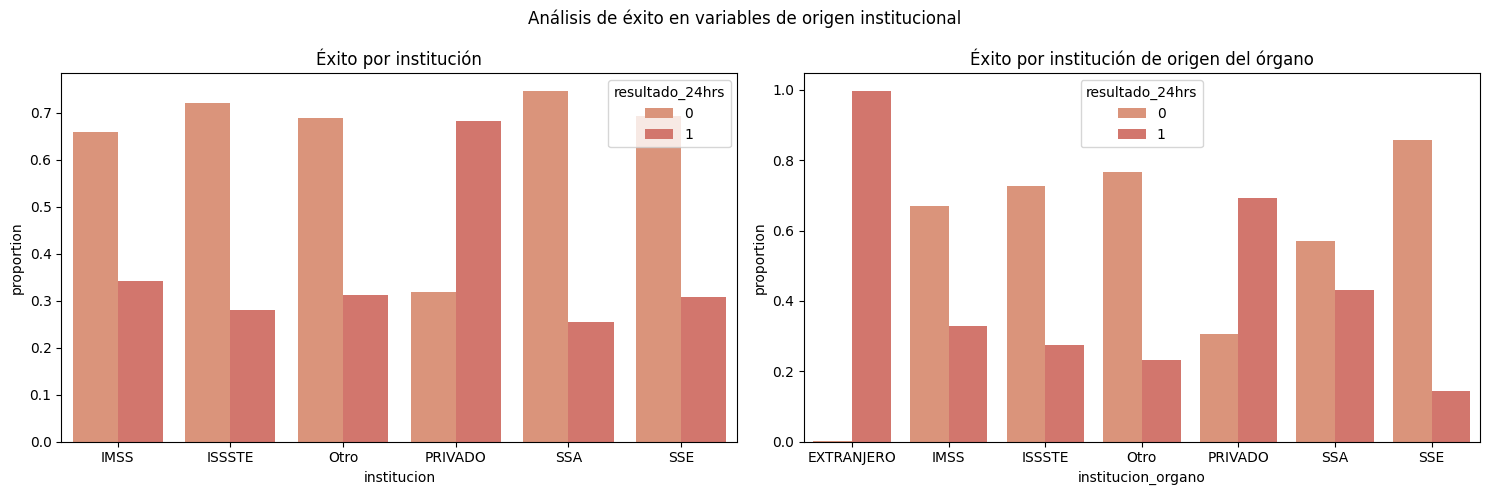

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Análisis de éxito en variables de origen institucional")

institución = dict_df_normalizados["institucion"]
sns.barplot(data = institución, x = "institucion", ax = axes[0], hue = "resultado_24hrs", y = "proportion")
axes[0].set_title("Éxito por institución")

institución_órgano = dict_df_normalizados["institucion_organo"]
sns.barplot(data = institución_órgano, x = "institucion_organo", ax = axes[1], hue = "resultado_24hrs", y = "proportion")
axes[1].set_title("Éxito por institución de origen del órgano")

plt.tight_layout()
plt.show()

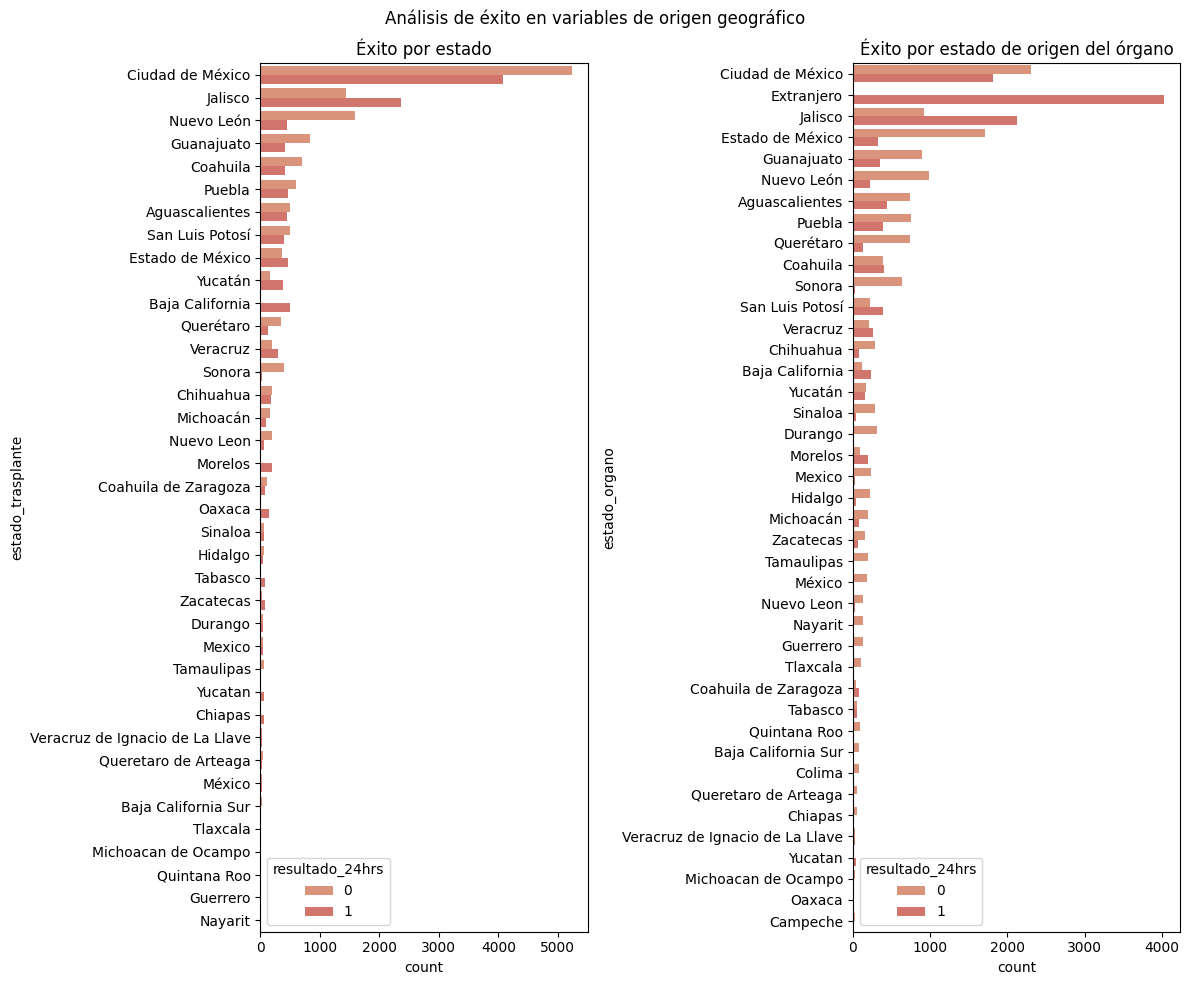

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 10))
fig.suptitle("Análisis de éxito en variables de origen geográfico")

# Ordenamos de  forma descendente los estados por conteo
estado_trasplante_orden = df['estado_trasplante'].value_counts().index
sns.countplot(data = df, y = "estado_trasplante", ax = axes[0], hue = "resultado_24hrs", order=estado_trasplante_orden)
axes[0].set_title("Éxito por estado")


estado_organo_orden = df['estado_organo'].value_counts().index
sns.countplot(data = df, y = "estado_organo", ax = axes[1], hue = "resultado_24hrs", order=estado_organo_orden)
axes[1].set_title("Éxito por estado de origen del órgano")

plt.tight_layout()
plt.show()

In [44]:
#Top 5 hospitales privados y públicos en CDMX y Jalisco

df_estados = pd.concat([df, df_base["establecimiento"]], axis = 1)
df_estados.dropna(inplace = True)
df_Jalisco = df_estados[(df_estados["estado_trasplante"] == "Jalisco") & (df_estados["resultado_24hrs"] == 1)]
df_CDMX = df_estados[(df_estados["estado_trasplante"] == "Ciudad de México") & (df_estados["resultado_24hrs"] == 1)]

In [46]:
print("Top 5 mejores hospitales públicos y privados en Jalisco:\n")
df_Jalisco_temp = df_Jalisco[df_Jalisco["institucion"] != "PRIVADO"]
print(df_Jalisco_temp.groupby("institucion")["establecimiento"].value_counts().sort_values(ascending = False).head())

df_Jalisco_temp = df_Jalisco[df_Jalisco["institucion"] == "PRIVADO"]
print()
print(df_Jalisco_temp.groupby("institucion")["establecimiento"].value_counts().sort_values(ascending = False).head())


Top 5 mejores hospitales públicos y privados en Jalisco:

institucion  establecimiento                                                                                                                 
IMSS         Unidad Medica de Alta Especialidad Hospital de Especialidades del Centro Medico Nacional de Occidente Lic. Ignacio Garcia Tellez    156
             Hospital Puerta de Hierro Sur                                                                                                        63
             U.M.A.E. Hospital de Especialidades No. 71                                                                                           55
             U.M.A.E. Hospital de Especialidades "Dr. Antonio Fraga Mouret" del Centro Medico Nacional La Raza                                    39
             Unidad Medica de Alta Especialidad Doctor Gaudencio Gonzalez Garza Centro Medico Nacional La Raza                                    39
Name: count, dtype: int64

institucion  establecimiento

In [32]:
print("Top 5 mejores hospitales públicos y privados en Ciudad de México:\n")
df_CDMX_temp = df_CDMX[df_CDMX["institucion"] != "PRIVADO"]
print(df_CDMX_temp.groupby("institucion")["establecimiento"].value_counts().sort_values(ascending = False).head())

df_CDMX_temp = df_CDMX[df_CDMX["institucion"] == "PRIVADO"]
print()
print(df_CDMX_temp.groupby("institucion")["establecimiento"].value_counts().sort_values(ascending = False).head())

Top 5 mejores hospitales públicos y privados en Ciudad de México:

institucion  establecimiento                                                                                                                 
IMSS         Unidad Medica de Alta Especialidad Hospital de Especialidades del Centro Medico Nacional de Occidente Lic. Ignacio Garcia Tellez    98
             Hospital Puerta de Hierro Sur                                                                                                       63
             U.M.A.E. Hospital de Especialidades No. 71                                                                                          59
             U.M.A.E. Hospital de Especialidades "Dr. Antonio Fraga Mouret" del Centro Medico Nacional La Raza                                   51
             Unidad Medica de Alta Especialidad Doctor Gaudencio Gonzalez Garza Centro Medico Nacional La Raza                                   47
Name: count, dtype: int64

institucion  establecimi

In [55]:
print("Top 10 mejores hospitales públicos y privados del país:\n")
df_estados_temp = df_estados[df_estados["institucion"] != "PRIVADO"]
print(df_estados_temp.groupby("institucion")["establecimiento"].value_counts().sort_values(ascending = False).head(10))
print()
df_estados_temp = df_estados[df_estados["institucion"] == "PRIVADO"]
print(df_estados_temp.groupby("institucion")["establecimiento"].value_counts().sort_values(ascending = False).head(10))

Top 10 mejores hospitales públicos y privados del país:

institucion  establecimiento                                                                                                                 
IMSS         Unidad Medica de Alta Especialidad Hospital de Especialidades del Centro Medico Nacional de Occidente Lic. Ignacio Garcia Tellez    949
             Unidad Medica de Alta Especialidad Doctor Gaudencio Gonzalez Garza Centro Medico Nacional La Raza                                   820
             U.M.A.E. Hospitales de Especialidades del Centro Medico Nacional                                                                    741
             U.M.A.E. Hospital de Especialidades No. 71                                                                                          532
             U.M.A.E. Hospital de Especialidades No. 25                                                                                          497
             U.M.A.E. Hospital de Especialidades C.M.N. 

/tmp/ipython-input-1362778136.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(['Relacionado' if label.get_text() == '1' else 'No relacionado' for label in axes[1,0].get_xticklabels()])


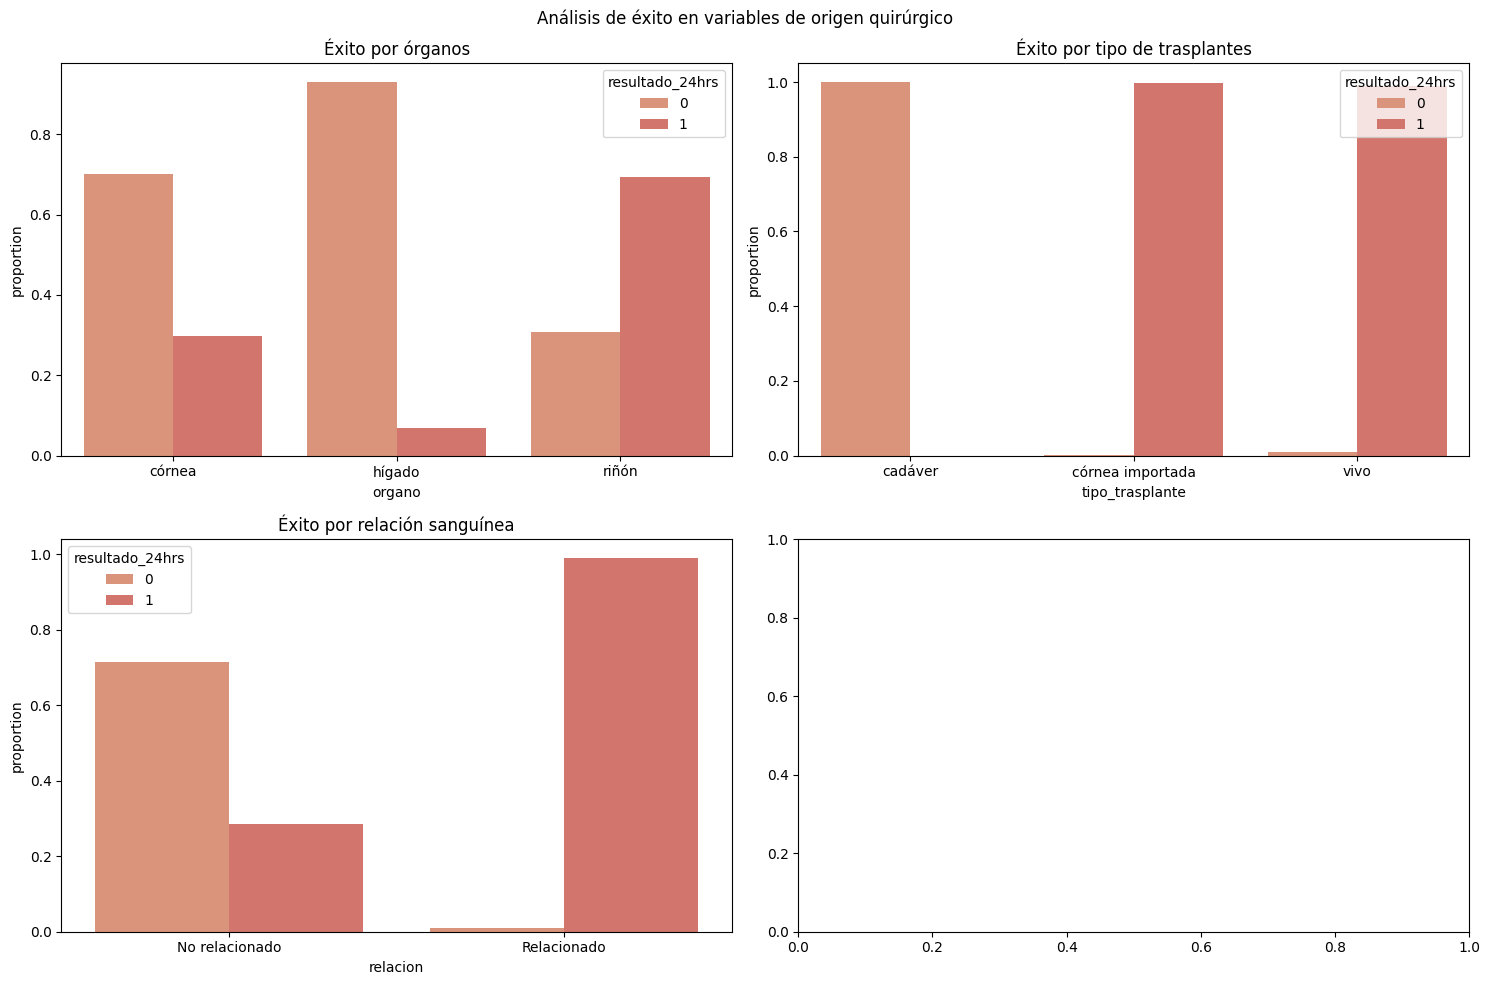

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Análisis de éxito en variables de origen quirúrgico")

órgano = dict_df_normalizados["organo"]
sns.barplot(data = órgano, x = "organo", ax = axes[0,0], hue = "resultado_24hrs", y = "proportion")
axes[0,0].set_title("Éxito por órganos")

trasplante = dict_df_normalizados["tipo_trasplante"]
sns.barplot(data = trasplante, x = "tipo_trasplante", ax = axes[0,1], hue = "resultado_24hrs", y = "proportion")
axes[0,1].set_title("Éxito por tipo de trasplantes")

relación = dict_df_normalizados["relacion"]
sns.barplot(data = relación, x = "relacion", ax = axes[1,0], hue = "resultado_24hrs", y = "proportion")
axes[1,0].set_title("Éxito por relación sanguínea")
axes[1,0].set_xticklabels(['Relacionado' if label.get_text() == '1' else 'No relacionado' for label in axes[1,0].get_xticklabels()])


plt.tight_layout()
plt.show()

## 5. Estadística Descriptiva

De todas las variables disponibles, solo una es numérica y las demás son nominales.

- Para resumir la variable numérica (edad) podemos utilizar la media y desviación estándar, ya que no sufre de outliers.

- Para resumir las variables nominales solo podemos usar la moda o una lista de las clases con proporción más alta.

Al tener estas estadísticas en el análisis univariado podemos ver qué tan sesgados están nuestros datos (si hay más hombres que mujeres en los datos, por ejemplo).

En el análisis bivariado (con respecto a la variable objetivo) podemos diferenciar las variables que influyen más (gran diferencia de proporción entre clases) en tener un resultado positivo en el resultado (1).

De la sección anterior, podemos resaltar que:

- Las mujeres tienen alrededor de un 10% menos de probabilidad de éxito en el trasplante.

- Los pacientes atendidos en hospitales privados tienen alrededor de 70% de probabilidad de éxito, mientras que los pacientes atendidos en instituciones públicas tienen una probabilidad de éxito del 30%.
- Jalisco es el único estado donde la proporción mayor es la de éxito.
- Las variables "tipo_trasplate" y "relacion" tienen proporciones cerca del 100% de éxito dependiendo de sus valores.

En esta sección utilizamos el coeficiente de Theils's U para determinar la correlación categórica-categórica.

Usamos esta prueba ya que la mayoría de nuestras variables son categóricas, y no sería correcto utilizar la matriz de correlación usual (Pearson), ya que solo es válido entre variables numéricas.

Los coficientes son direccionales y son de la forma

$$H(Y|X) \neq H(X|Y)$$
<br>

$H(Y|X) = 0$ : Significa que X no proporciona ninguna información acerca de Y.<br>

$H(Y|X) = 1$ : Significa que X predice perfectamente Y.

En la siguiente matriz, los coeficientes tienen la forma $H(fila|columna)$.


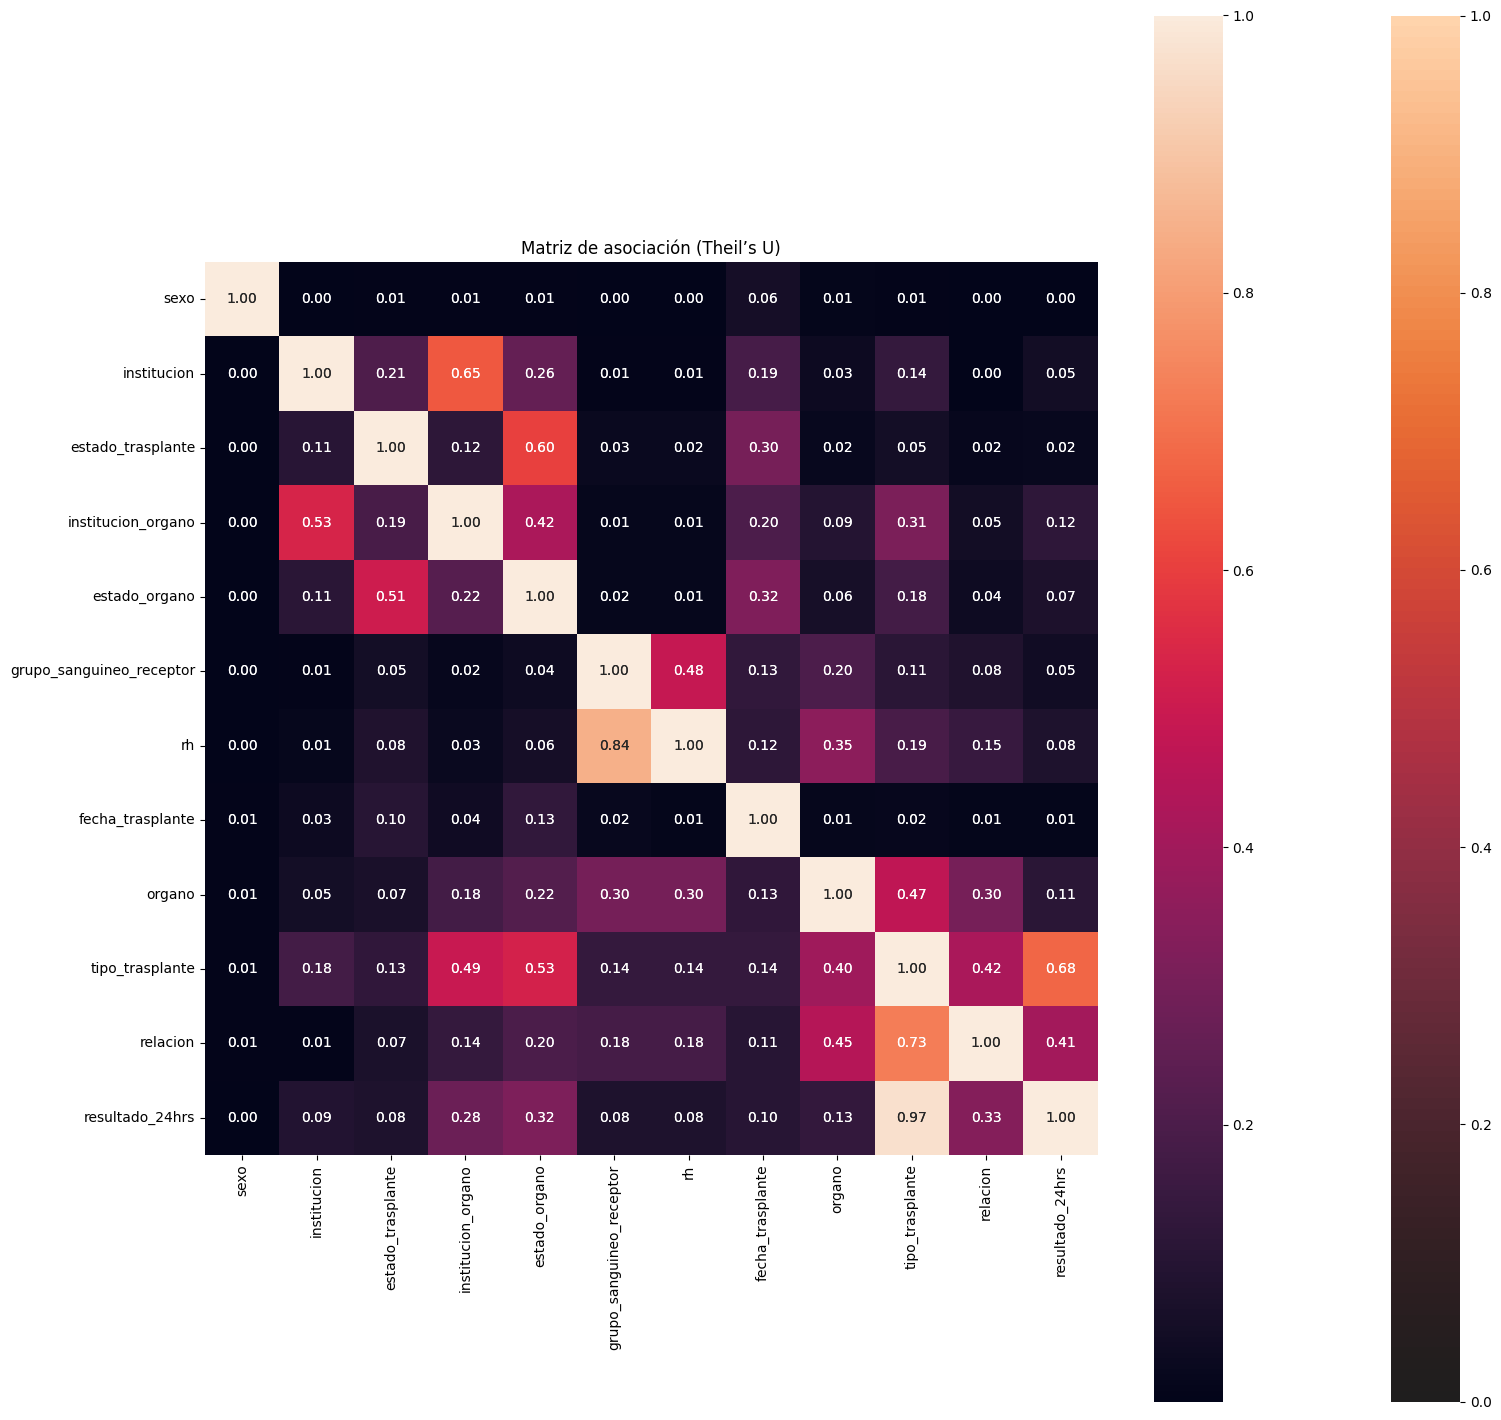

In [62]:
Nominal_df = df.drop("edad", axis = 1)
Matrix = associations(Nominal_df, nominal_columns = Nominal_df.columns, nom_nom_assoc = "theil", plot = False)


sns.heatmap(Matrix['corr'], annot=True, fmt=".2f")
plt.title("Matriz de asociación (Theil’s U)")
plt.show()


En esta matriz podemos inferir que hay poca correlación entre las variables, la fila de interés es la de nuestra variable objetivo, donde vemos que tiene un coeficiente de 0.97 con la variable "tipo_trasplante", donde veremos el efecto de este en nuestros modelos de predicción.

## 6. Inferencia Estadística

Para realizar una prueba de hipótesis comparando dos grupos, compararemos la media de la variable 'edad' entre las personas que su trasplante fue exitoso y no exitoso, utilizando la variable objetivo 'resultado_24hrs'.

**Planteamiento de la prueba de hipótesis:**

*   **Variable de interés:** `edad` (edad, variable continua)
*   **Grupos a comparar:** Individuos con `resultado_24hrs` = 0 (no exitoso) e Individuos con `resultado_24hrs` = 1 (exitoso)

*   **Hipótesis Nula ($\mu_0$):** La media de la edad es la misma independientemente del resultado del trasplante.
    $$\mu_0 = \mu_1$$
    

*   **Hipótesis Alternativa ($\mu_1$):** La media de la edad es diferente para los individuos con resultado exitoso con respecto a los que tuvieron el resultado no exitoso.
    μ₀ ≠ μ₁
    (Esta es una prueba bilateral).

*   **Nivel de Significancia ($\alpha$):** Elegiremos un nivel de significancia común de $\alpha$ = 0.05.

**Justificación de la prueba utilizada:**

Utilizaremos una **prueba t de Student para muestras independientes (Independent Samples t-test)**. Esta prueba es apropiada porque estamos comparando las medias de una variable continua entre dos grupos independientes.


In [61]:
from scipy import stats

# Separar los datos en dos grupos basados en la variable 'resultado_24hrs'
grupo_no_exitoso = df[df['resultado_24hrs'] == 0]['edad']
grupo_exitoso = df[df['resultado_24hrs'] == 1]['edad']

# Verificar el tamaño de los grupos
print(f"Tamaño del grupo con trasplante no exitoso (resultado_24hrs = 0): {len(grupo_no_exitoso)}")
print(f"Tamaño del grupo con trasplante exitoso (resultado_24hrs = 1): {len(grupo_exitoso)}")

# Analizamos las diferencias de varianza entre los grupos
equalvar =  abs((np.var(grupo_no_exitoso)-np.var(grupo_exitoso))/(np.var(grupo_no_exitoso)+np.var(grupo_exitoso)))*100
print(f'Diferencia porcentual de las varianzas de las poblaciones: {equalvar:.2f}%')


# Realizar la prueba t de Student para muestras independientes
# stats.ttest_ind asume por defecto varianzas iguales (prueba t estándar).
ttest_result = stats.ttest_ind(grupo_no_exitoso, grupo_exitoso)
pvalue = ttest_result.pvalue

# Imprimir los resultados de la prueba
print("\nResultados de la prueba t de Student para muestras independientes:")
print(f"Estadístico t: {ttest_result.statistic:.4f}")
print(f"Valor p: {pvalue:.4f}")

# Tomar una decisión basada en el valor p y el nivel de significancia (alpha)
alpha = 0.05


if pvalue < alpha:

  print("Rechazamos la hipótesis nula")
  print("Conclusión: Existe una diferencia estadísticamente significativa en la edad media entre los grupos de trasplante exitoso y no exitoso.")
else:
  print("No podemos rechazar la hipótesis nula")
  print("Conclusión: No hay suficiente evidencia para concluir que existe una diferencia estadísticamente significativa en la edad media entre los grupos de trasplante exitoso y no exitoso.")

# Mostrar las medias de cada grupo para entender la dirección de la diferencia si es significativa
print()
print(f"Media de edad para el grupo con trasplante no exitoso (resultado_24hrs = 0): {grupo_no_exitoso.mean():.4f}")
print(f"Media de edad para el grupo con trasplante exitoso (resultado_24hrs = 1): {grupo_exitoso.mean():.4f}")

Tamaño del grupo con trasplante no exitoso (resultado_24hrs = 0): 14039
Tamaño del grupo con trasplante exitoso (resultado_24hrs = 1): 12161
Diferencia porcentual de las varianzas de las poblaciones: 7.53%

Resultados de la prueba t de Student para muestras independientes:
Estadístico t: 21.2971
Valor p: 0.0000
Rechazamos la hipótesis nula
Conclusión: Existe una diferencia estadísticamente significativa en la edad media entre los grupos de trasplante exitoso y no exitoso.

Media de edad para el grupo con trasplante no exitoso (resultado_24hrs = 0): 47.9833
Media de edad para el grupo con trasplante exitoso (resultado_24hrs = 1): 42.8691


## 7.- Modelo predictivo
### Preparación de los datos para introducirlos a los modelos

Para todos los modelos, la preparación de datos es la misma:

- Separamos los datos en entrenamiento y testeo.
- Escalamos la variable numérica con StandardScaler.
- Transformamos las variables nominales con TargetEncoder.

Utilizaremos los modelos de Regresión Logística, Árbol de decisión y Red Neuronal. Todos usan el mismo principio pero a diferentes modos de complejidad, teniendo mayor precisión pero pero a su vez, mayor tiempo de cálculo.

In [65]:
# Dividimos las variables dependientes de la independiente, y separamos los datos de entrenamiento y testeo.

from sklearn.model_selection import train_test_split

X = df.drop("resultado_24hrs", axis=1)
y = df["resultado_24hrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [66]:
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.compose import ColumnTransformer

# Separamos las columnas categóricas y numéricas

# Para las columnas categóricas usaremos TargetEncoder ya que tenemos muchas clases en cada variable.

Cols_categóricas = X.select_dtypes(include='object').columns.to_list()

Col_numérica = X.select_dtypes(include=['int64', 'float64']).columns.to_list()

preprocessor = ColumnTransformer([
    ('target_enc', TargetEncoder(), Cols_categóricas),
    ('scaler', StandardScaler(), Col_numérica)
])

X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_test_transformed = preprocessor.transform(X_test)

### Regresión logística

Ya que tenemos un problema de clasificación binaria, la regresión logística es el modelo índicado.

La regresión logística transforma el valor devuelto por la regresión lineal con una función cuyo resultado siempre está comprendido entre 0 y 1.

$$f(x) = σ(x) = \frac{1}{1+\exp(-[\beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + ϵ])}$$
<br>

Utilizaremos la validación cruzada para encontrar el mejor valor del hiperparámetro C.

In [67]:
from sklearn.linear_model import LogisticRegressionCV


# Entrenamiento del modelo

Regresión = LogisticRegressionCV(cv = 5, scoring = "f1", random_state = 42, n_jobs = -1)

# Entrenamiento
Regresión.fit(X_train_transformed, y_train)

# El mejor valor de C encontrado
print(f"Mejor parámetro C encontrado: {Regresión.C_[0]:.2f}\n")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Mejor parámetro C encontrado: 0.01



In [71]:
# Coeficientes e intercepto

print('beta_0:', Regresión.intercept_)
print('beta_1:', Regresión.coef_)


beta_0: [-3.64855698]
beta_1: [[ 0.45005182  0.26029547  1.16318127  1.21341328  0.25090879  0.24978906
   0.17381642  0.39767369  3.37770189 -0.05108994 -0.00773502  1.11115868]]


In [72]:
# Predicciones

y_pred_Regresión = Regresión.predict(X_test_transformed)

### Árbol de decisión



Los árboles de decisión aplican la regresión lineal / logística dependiendo del caso, donde cada nodo separa los datos con respecto a sus propiedades, donde en cada decisión prioriza la minimización de su función de coste (entropía, coeficiente de gini).

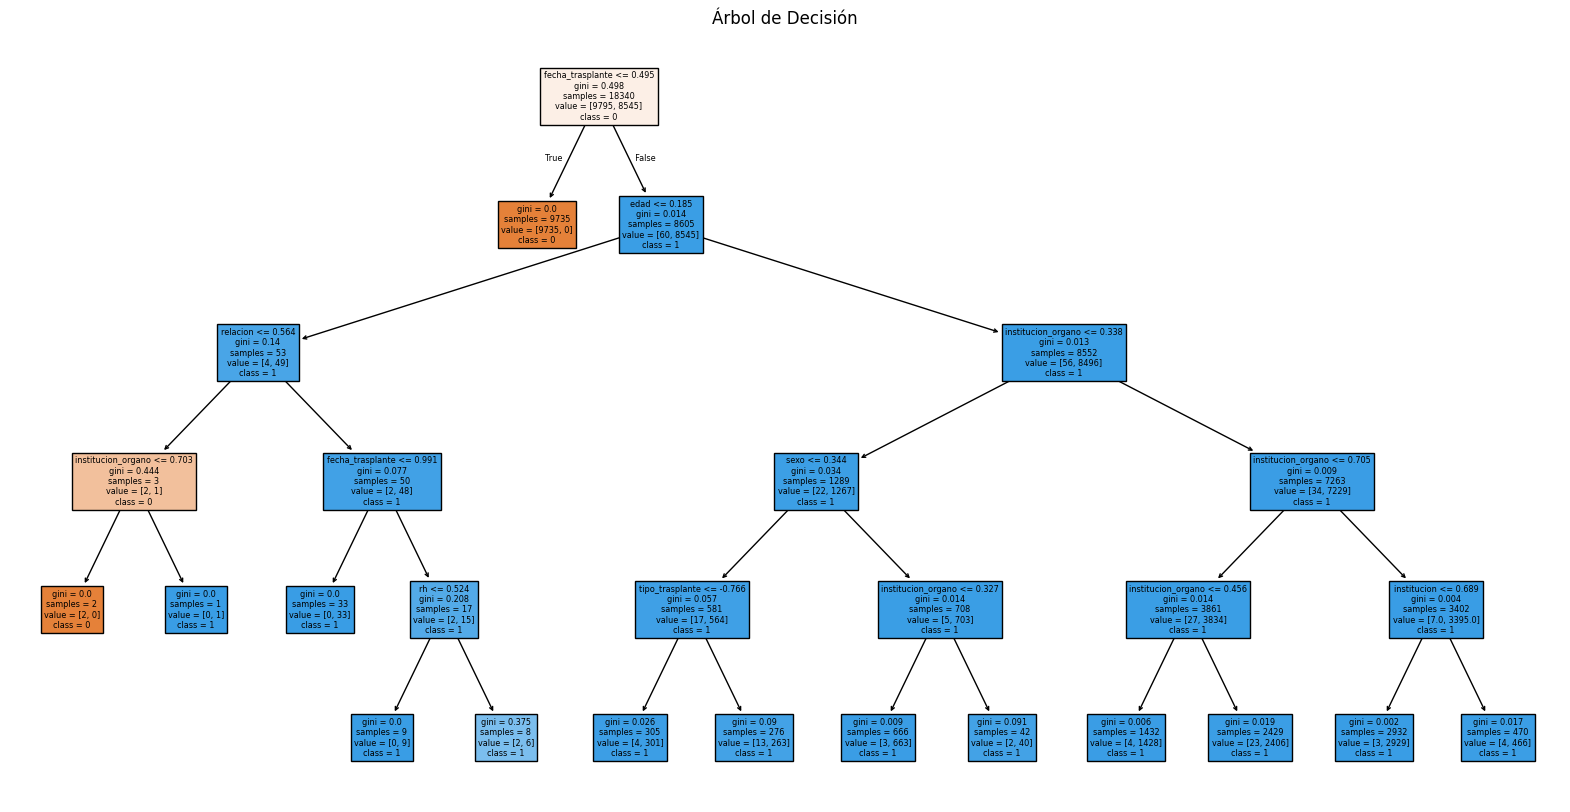

In [77]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train_transformed, y_train)

y_pred_tree = tree.predict(X_test_transformed)

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns, class_names=["0", "1"], filled=True)
plt.title("Árbol de Decisión")
plt.show()

### Red Neuronal

In [97]:
# Ventaneo temporal

def create_sequences(data, target, window_size, step_size):
    X_rnn, y_rnn = [], []
    for i in range(0, len(data) - window_size + 1, step_size):
        X_rnn.append(data[i:i + window_size])
        y_rnn.append(target[i + window_size - 1]) # Target corresponds to the last element of the window
    return np.array(X_rnn), np.array(y_rnn)


In [98]:
window_size = 5 # Ejemplo
step_size = 1   # Ejemplo

X_train_rnn, y_train_rnn = create_sequences(X_train_transformed, y_train.to_numpy(), window_size, step_size)
X_test_rnn, y_test_rnn = create_sequences(X_test_transformed, y_test.to_numpy(), window_size, step_size)

print("Verificación de dimensiones:\n")
print(f"Shape of X_train_rnn: {X_train_rnn.shape}")
print(f"Shape of y_train_rnn: {y_train_rnn.shape}")
print(f"Shape of X_test_rnn: {X_test_rnn.shape}")
print(f"Shape of y_test_rnn: {y_test_rnn.shape}")

Verificación de dimensiones:

Shape of X_train_rnn: (18336, 5, 12)
Shape of y_train_rnn: (18336,)
Shape of X_test_rnn: (7856, 5, 12)
Shape of y_test_rnn: (7856,)


Construcción de la RNN

In [108]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.metrics import AUC, Accuracy, FalseNegatives, FalsePositives, Precision, Recall, TrueNegatives, TruePositives

model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
metrics =[
    AUC(),
    Accuracy(),
    FalseNegatives(),
    FalsePositives(),
    Precision(),
    Recall(),
    TrueNegatives(),
    TruePositives()
]
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=metrics)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 8. Evaluación de Modelos

En este proceso de clasificación utilizaremos las métricas de F1-score, precisión, recall y exactitud, visualizando también matrices de confusión.

### Regresión Logística

F1 = 0.996, Exactitud  = 0.996

Precisión = 0.991, Sencibilidad = 1.000



Text(0.5, 1.0, 'Matriz de Confusión (Regresión Logística)')

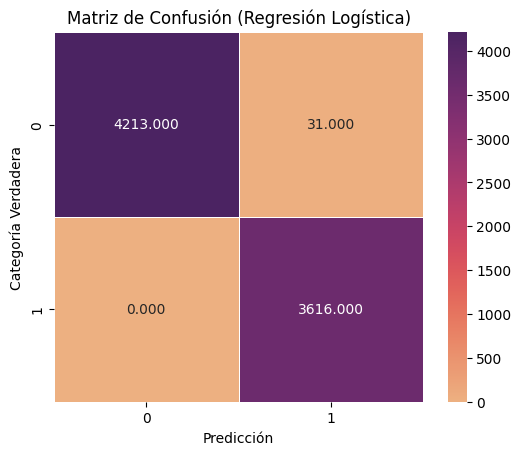

In [87]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

accuracy_r = accuracy_score(y_true = y_test, y_pred = y_pred_Regresión)
f1_r = f1_score(y_true = y_test, y_pred = y_pred_Regresión)
precision_r = precision_score(y_true = y_test, y_pred = y_pred_Regresión)
recall_r = recall_score(y_true = y_test, y_pred = y_pred_Regresión)

print(f"F1 = {f1_r:.3f}, Exactitud  = {accuracy_r:.3f}\n")
print(f"Precisión = {precision_r:.3f}, Sencibilidad = {recall_r:.3f}\n")


cm = confusion_matrix(y_test, y_pred_Regresión)

sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'flare')
plt.ylabel('Categoría Verdadera')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión (Regresión Logística)')

AUC = 1.00



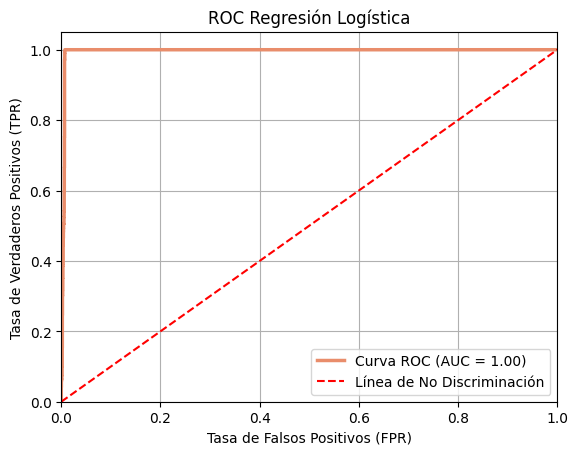

In [112]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = Regresión.predict_proba(X_test_transformed)[::, 1]

# Calcular la curva ROC (FPR, TPR, Umbrales)
FPR, TPR, umbrales = roc_curve(y_test, y_pred_proba)

# Calcular el Área Bajo la Curva (AUC)
auc_score = auc(FPR, TPR)

print(f"AUC = {auc_score:.2f}\n")


# Graficar la curva ROC
plt.plot(FPR, TPR, label=f'Curva ROC (AUC = {auc_score:.2f})', lw = 2.5)
plt.plot([0, 1], [0, 1], 'r--', label='Línea de No Discriminación') # Línea de 45 grados
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('ROC Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Árbol de decisión

F1 = 0.996, Exactitud  = 0.995

Precisión = 0.991, Sencibilidad = 0.998



Text(0.5, 1.0, 'Matriz de Confusión (Árbol de decisión)')

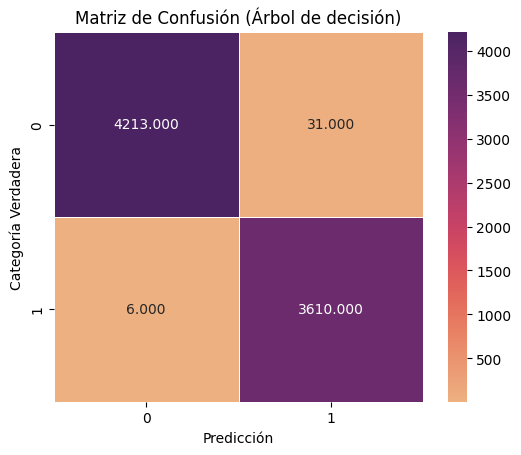

In [90]:
accuracy_a = accuracy_score(y_true = y_test, y_pred = y_pred_tree)
f1_a = f1_score(y_true = y_test, y_pred = y_pred_tree)
precision_a = precision_score(y_true = y_test, y_pred = y_pred_tree)
recall_a = recall_score(y_true = y_test, y_pred = y_pred_tree)

print(f"F1 = {f1_r:.3f}, Exactitud  = {accuracy_a:.3f}\n")
print(f"Precisión = {precision_a:.3f}, Sencibilidad = {recall_a:.3f}\n")


cm = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'flare')
plt.ylabel('Categoría Verdadera')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión (Árbol de decisión)')

AUC = 1.00



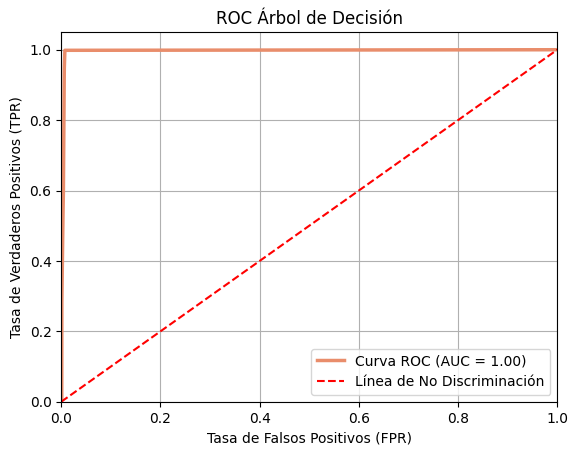

In [113]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = tree.predict_proba(X_test_transformed)[::, 1]

# Calcular la curva ROC (FPR, TPR, Umbrales)
FPR, TPR, umbrales = roc_curve(y_test, y_pred_proba)

# Calcular el Área Bajo la Curva (AUC)
auc_score = auc(FPR, TPR)

print(f"AUC = {auc_score:.2f}\n")


# Graficar la curva ROC
plt.plot(FPR, TPR, label=f'Curva ROC (AUC = {auc_score:.2f})', lw = 2.5)
plt.plot([0, 1], [0, 1], 'r--', label='Línea de No Discriminación') # Línea de 45 grados
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('ROC Árbol de Decisión')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Red Neuronal

In [109]:
history = model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=5,
    verbose=2,
    validation_data=(X_test_rnn, y_test_rnn),
)

Epoch 1/5
573/573 - 6s - 11ms/step - accuracy: 0.0000e+00 - auc_3: 0.9865 - false_negatives_3: 778.0000 - false_positives_3: 351.0000 - loss: 0.1734 - precision_4: 0.9567 - recall_4: 0.9089 - true_negatives_3: 9444.0000 - true_positives_3: 7763.0000 - val_accuracy: 0.0000e+00 - val_auc_3: 0.9960 - val_false_negatives_3: 2.0000 - val_false_positives_3: 31.0000 - val_loss: 0.0351 - val_precision_4: 0.9915 - val_recall_4: 0.9994 - val_true_negatives_3: 4210.0000 - val_true_positives_3: 3613.0000
Epoch 2/5
573/573 - 3s - 4ms/step - accuracy: 0.0000e+00 - auc_3: 0.9972 - false_negatives_3: 38.0000 - false_positives_3: 64.0000 - loss: 0.0341 - precision_4: 0.9925 - recall_4: 0.9956 - true_negatives_3: 9731.0000 - true_positives_3: 8503.0000 - val_accuracy: 0.0000e+00 - val_auc_3: 0.9966 - val_false_negatives_3: 0.0000e+00 - val_false_positives_3: 31.0000 - val_loss: 0.0284 - val_precision_4: 0.9915 - val_recall_4: 1.0000 - val_true_negatives_3: 4210.0000 - val_true_positives_3: 3615.0000
Epo

Media de las métricas:

- Val_AUC = 0.99
- Val_FN = 0.4
- Val_FP = 31
- Val_loss = 0.02782
- Val_precision = 0.99
- Val_recall = 0.99
- Val_TN = 4210
- Val_TP = 3614.6

Observando las metricas, las métricas de la red neuronal son muy similares a los modelos pasados (casi perfectos).

## 9. Comparación del peor, modelo intermedio y mejor modelo

- **Peor modelo**: Red Neuronal
- **Modelo intermedio**: Árbol de decisión
- **Mejor modelo** : Regresión logística

En el problema planteado, es más importante darle la atención a la precisión, ya que nos queremos enfocar en los pacientes con riesgo de que su trasplante sea no exitoso.

Ya que todos los modelos tuvieron la misma calidad en cuanto métricas de precisión, recall, etc, lo que los diferencia es su robustez y tiempo de cálculo.

Debido a que los datos contienen variables (como ´relacion´) de los que el resultado depende fuertemente, con una regresión logística es suficiente para tener muy buenos resultados, por lo que los demás modelos pueden sufrir de overfitting, además que estos consumen más recursos que la regresión logística.

Es esencial minimizar el consumo de recursos y escoger la solución óptima.


## 10. Conclusiones Generales

Redacta las conclusiones generales que esperas poder obtener a partir del análisis completo. En particular, reflexiona sobre:

- Los hallazgos más importantes que el proyecto podría revelar sobre el fenómeno estudiado.
- El modelo o tipo de modelo que consideras más adecuado para tu problema y por qué.
- Las limitaciones del proyecto (por ejemplo, tamaño de muestra, calidad de los datos, supuestos de los modelos, etc.).
- Posibles extensiones o trabajo futuro (nuevos datos, modelos adicionales, mejoras metodológicas, etc.).

Redacta esta sección como si se tratara del cierre de un informe académico formal.


Factores clave de éxito:
- Institución: Las personas que fueron operadas en una institución privada tuvieron una alta tasa de éxito
- Relación con el donante: Las personas cuyo órgano fue donado por algún familiar tuvo una tasa de éxito de casi el 100%
- Estado del donante: Si el trasplante es de un paciente vivo, la tasa de éxito es cercano al 100%
- Órigen institucional del órgano: Órganos provenientes del extranjero o sector privado tienen altas tasas de éxito.

Modelo:

- Como ya justificamos en la sección pasada, el modelo más adecuado para predecir la variable objetivo sin consumir tantos recursos es la Regresión Lineal.

Limitaciones:

- Los datos no contiene muchas variables biológicas del paciente que pueden tomar un papel importante en el resultado de la cirugía, tal como examenes clínicos, presión arterial, etc.

Trabajo a futuro:

- Conforme se vaya actualizando la base datos esperamos poder analizar las cirugías con los órganos no estudiados, tales como corazón, riñón-riñón, etc.

## 11. Referencias

- Minkovich, M., Gupta, N., Liu, M., Famure, O., Li, Y., Selzner, M., Lee, J. Y., Kim, S. J., & Ghanekar, A. (2024). Impact of early surgical complications on kidney transplant outcomes. BMC Surgery, 24(1), 165. https://doi.org/10.1186/s12893-024-02463-7

- Poggio, E. D., Augustine, J. J., Arrigain, S., Brennan, D. C., & Schold, J. D. (2020). Long-term kidney transplant graft survival—Making progress when most needed. American Journal Of Transplantation, 21(8), 2824-2832. https://doi.org/10.1111/ajt.16463
- Gurnani, B., Czyz, C. N., Mahabadi, N., & Havens, S. J. (2023, 11 junio). Corneal graft rejection. StatPearls - NCBI Bookshelf. https://www.ncbi.nlm.nih.gov/books/NBK519043/

- Pozo-Laderas, J., Guler, I., Rodríguez-Perálvarez, M., Robles, J., Mula, A., López-Cillero, P., & De la Fuente, C. (2021). Early postoperative mortality in liver transplant recipients involving indications other than hepatocellular carcinoma. A retrospective cohort study. Medicina Intensiva (English Edition), 45(7), 395-410. https://doi.org/10.1016/j.medine.2020.02.004

- Zychlinski, S. (s. f.). dython:nominal. https://shakedzy.xyz/dython/modules/nominal/

- Lee, S. (s. f.). Your Quick Guide to Theil’s U Statistic for Data Science. https://www.numberanalytics.com/blog/quick-guide-theils-u-statistic-data-science

- Comparing Target Encoder with Other Encoders. (s. f.). Scikit-learn. https://scikit-learn.org/stable/auto_examples/preprocessing/plot_target_encoder.html#